In [1]:
# Boyko, J.D., O’Meara, B.C. and Beaulieu, J.M. (2023) “A novel method for jointly modeling the evolution of discrete and continuous traits,” Evolution, 77(3), pp. 836–851.
# Available at: https://doi.org/10.1093/evolut/qpad002.
# try and reproduce the analyses of the above paper to get comfortable with the OUwie stuff

In [8]:
# code repo - https://github.com/tncvasconcelos/seed_dispersal
# code repo - https://github.com/jboyko/2020_houwie
# look up https://github.com/jboyko/2020_houwie/blob/master/04_empirical-seed-dispersal.R for reference

In [3]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("nlme")
    library("corHMM")
    library("geiger")
    library("mkcor")
    library("OUwie")
    library("reshape2")
    library("ggplot2")
})

In [6]:
# pick family Ericaceae

# # we don't want the other unnecessary columns
# fruits <- read.csv("../R/thirdparty/seed_dispersal/trait_dataa/Ericaceae_trait_dataa.csv")[, c("Species", "Fruit_type")]
# fruits <- fruits[fruits$Fruit_type == "Fleshy" | fruits$Fruit_type == "Dry", ] # drop the rows that do not have actual data for life form
# # Fruit_type is a binary discrete categorical trait with values Fleshy and Dry
# fruits$Fruit_type |> table()
# dim(fruits ) # 444 species

# continuous traits
climate <- read.csv("../../R/thirdparty/seed_dispersal/trait_data/Ericaceae_niche.csv") # looks like this too has the fruit type info embedded
climate$Fruit_type |> table()


   Dry Fleshy 
   158    151 

In [7]:
# load in the phylogenetic tree for Ericaceae
tree <- ape::read.tree("../../R/thirdparty/seed_dispersal/trees/Ericaceae_Schwery_etal_2015.tre")
stopifnot(ape::is.binary(tree))

In [10]:
# drop the species in the dataaset if they are not in the phylogenetic tree
species <- intersect(tree$tip.label, climate$species) # 309 species
indices <- match(species, climate$species)
data <- climate[indices, c("species", "Fruit_type", "mean_aridity", "se_aridity")]

In [11]:
# the standard error column has 43 NAs???
colSums(is.na(data))

species   Fruit_type mean_aridity   se_aridity 
           0            0            0           43

In [12]:
# update these with the mean of the se_aridity column (????)
data$se_aridity[is.na(data$se_aridity)] <- mean(data$se_aridity, na.rm = TRUE)

In [16]:
stopifnot(sum(is.na(data)) == 0) # make sure no NAs in the data
stopifnot(length(intersect(data$species, tree$tip.label)) == length(indices)) # make sure that we only have species for which there's data in the phylogeny

In [17]:
# see the mean of mean_aridity, grouped by fruit type
lapply(split(data, ~Fruit_type), FUN = function(df) { c(mean(df$mean_aridity), mean(df$se_aridity)) }) |> as.data.frame(row.names=c("mean", "SE"))

,Dry,Fleshy
,<dbl>,<dbl>
mean,9.32022626,8.89519592
SE,0.08538976,0.09167124


In [18]:
# drop the unnecessary species from the phylogeny
species_to_drop_from_tree <- setdiff(tree$tip.label, species) # order of the args matters here!!!
pruned_tree <- ape::drop.tip(phy = tree, tip = species_to_drop_from_tree)
stopifnot(all.equal(data$species, pruned_tree$tip.label)) # make sure the order of species match in data & the phylogeny

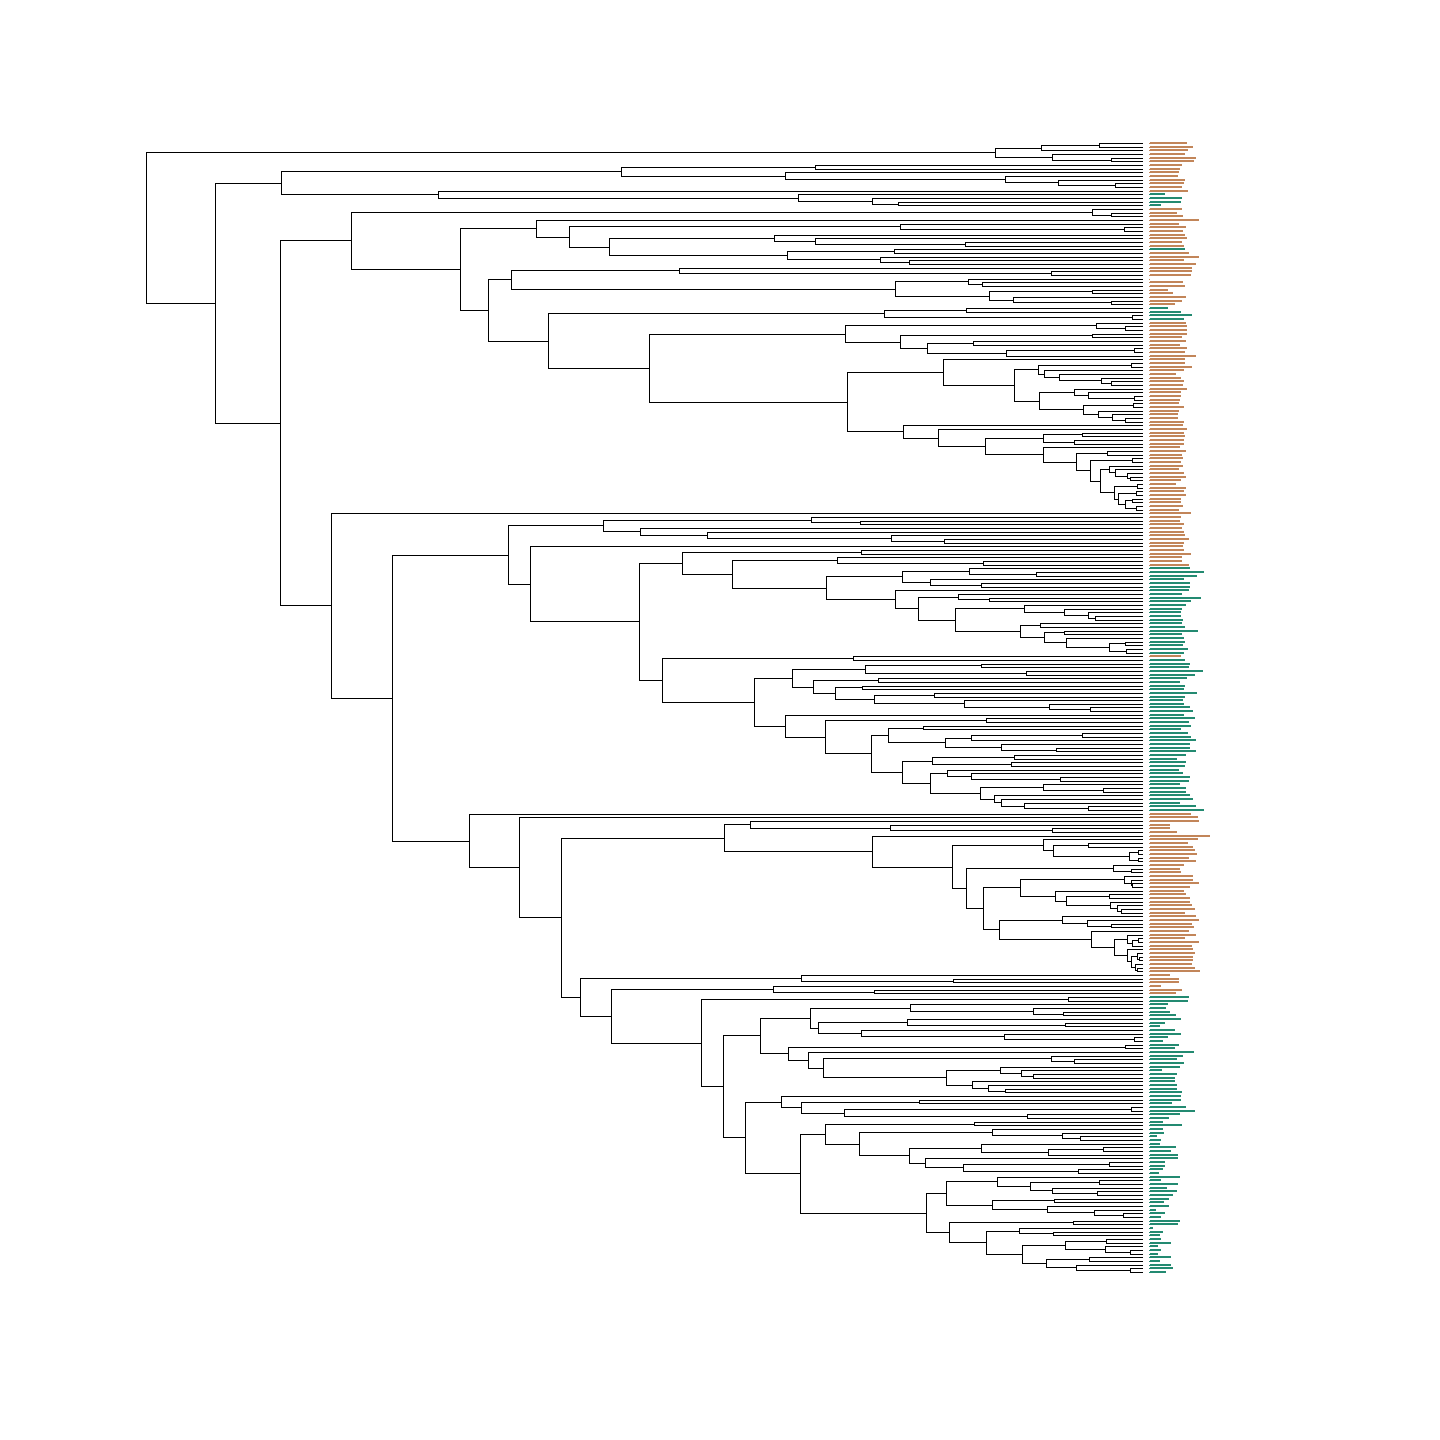

In [29]:
# visualize the pruned phylogeny with aridity index
options(repr.plot.width = 12, repr.plot.height = 12)
tmax <- max(ape::branching.times(pruned_tree))
plot(pruned_tree, show.tip.label = FALSE, x.lim = c(0, tmax + 0.2 * tmax))
start <- tmax + (0.0075 * tmax) # position to start the aridity index lines
aridity_index <- data$mean_aridity
# rescale the aridity index so the lines don't look too wide
scaled_aridity_index <- (aridity_index - min(aridity_index)) / max(aridity_index - min(aridity_index))
cols <- c("#C28559", "#238A71")
multiplier <- 7.0
for(i in 1:length(scaled_aridity_index)){
    lines(list(x = c(start, start + scaled_aridity_index[i] * multiplier), y = c(i, i)), col = cols[ifelse(data$Fruit_type[i] == "Dry", 1, 2)], lwd = 2)
}
# cool, Fig 5 on the paper is actually of mean aridity BUT IT IS NOT IDENTICAL TO OUR MANUALLY COMPUTED aridity_index????

In [ ]:
# character dependent rate category mat => gives a layout for the possible discrete state transitions
# for a discrete character state with two states e.g. dry & fleshy and only one rate category
# each rate category is represented by a separate process (evolutionary driver)
cd_discrete <- corHMM::getRateCatMat(length(unique(data$Fruit_type)))
#     R1 R2
# R1  0  2
# R2  1  0

# look up https://github.com/thej022214/corHMM/blob/master/vignettes/corHMMv2.1-vignette.pdf for a detailed walkthrough about
# discrete state transition rate categories

# character independent variants
# getFullMat combines several index matrices which describe transitions between observed states into output a single index matrix for use in corHMM
cid_discrete <- corHMM::getFullMat(StateMats = list(cd_discrete, cd_discrete), # rates for observed states and hidden states
                                   RateClassMat = corHMM::getRateCatMat(2)) # rate categories = 2
# below is what we got
# R1 stands for rate category 1 and R2 for rate category 2
#         (1,R1) (2,R1) (1,R2) (2,R2)
# (1,R1)      0      2      6      0
# (2,R1)      1      0      0      6
# (1,R2)      5      0      0      4
# (2,R2)      0      5      3      0

# with another state (hidden discrete character state), there are 4 x 4 transitions possible
#        (1,R1) (2,R1) (1,R2) (2,R2)
# (1,R1)    0      5      9     13
# (2,R1)    2      0     10     14
# (1,R2)    3      7      0     15
# (2,R2)    4      8     12      0

# TRANSITION RATE MATRICES ARE READ FROM ROW TO COLUMN

# but what we saw was different from this! this is because corHMM makes a simplyfying assumption that when a change in one discrete character is occurring
# another in the second discrete character cannot occur simultaneously. i.e (1, R1) can transition directly to (1, R2) or (2, R1) but not to (2, R2)
# in order for state (1, R1) to transition to (2, R2), it will have to go through either (1, R2) or (2, R1)
# again, look up the corHMM package vignette for a comprehensive explanation

# use the equateStateMatPars() function to create a "SYM" flavoured transition rate matrix, in which the ﬁrst argument is the rate matrix being modiﬁed (i.e., rate.mat object)
# and second argument is list of the parameters to be equated.
# one thing to note is that you must have the appropriate number of rate categories since a user rate matrix is not duplicated or changed by corHMM()

cid_discrete <- corHMM::equateStateMatPars(cid_discrete, list(c(1, 3), c(2, 4)))
# it now looks like
#        (1,R1) (2,R1) (1,R2) (2,R2)
# (1,R1)      0      2      6      0
# (2,R1)      1      0      0      6
# (1,R2)      5      0      0      4
# (2,R2)      0      5      3      0
